In [5]:
from IPython.display import Image
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error as MSE
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor


In [6]:
df = pd.read_csv(r"../Classification and Regression Trees/Regression/output_data.csv")
df = df.drop(["car_name","model_year","origin"],axis=1)

df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
print(df.head())
print(df.info())

    mpg  cylinders  displacement  horsepower  weight  acceleration
0  18.0          8         307.0       130.0  3504.0          12.0
1  15.0          8         350.0       165.0  3693.0          11.5
2  18.0          8         318.0       150.0  3436.0          11.0
3  16.0          8         304.0       150.0  3433.0          12.0
4  17.0          8         302.0       140.0  3449.0          10.5
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 18.8 KB
None


# Recall Bagging
- In bagging the base estimator could be any model : Decsion Tree , Logistic Regression , Neural Network
- Each estimator is trained on a distinct bootstrap sample of the training set 
- Estimators use all features for training and prediction

# Random Forest 
- Random forest is an ensemble method that uses a descision tree as a base estimator
- Each estimator is trained on a different bootstrap sample having the same size as the training set 
- Random forest further randomization in the training of individual trees
- When each tree is trained only d features can be sampled at each node without replacement , where d is a number smaller than the total number of features

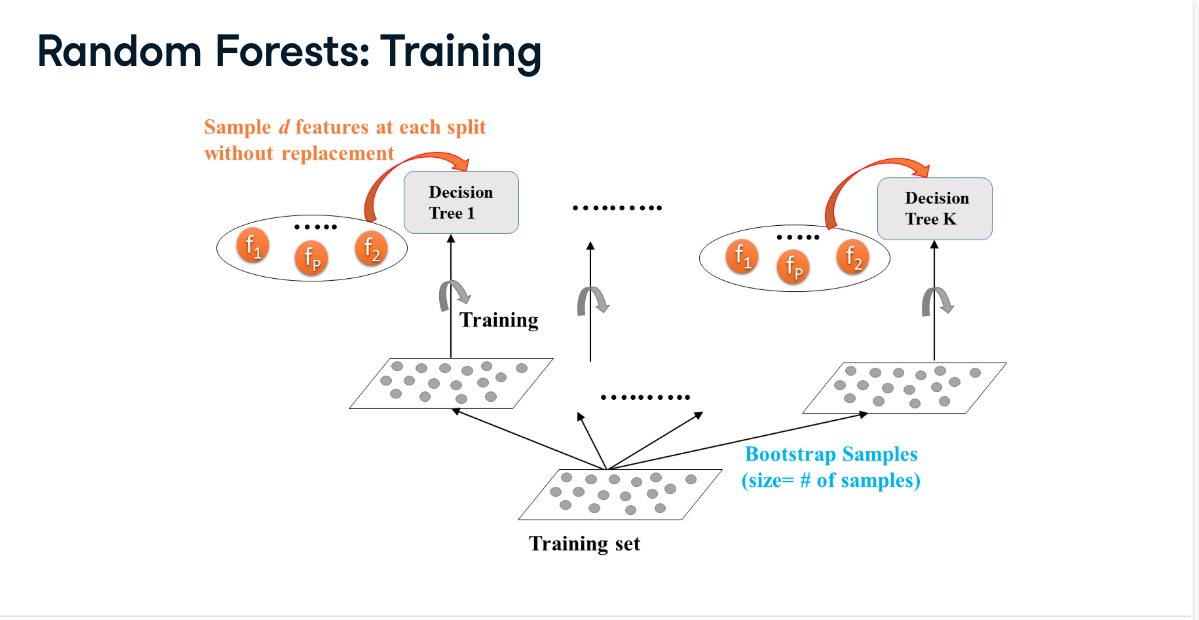


- The diagram here shows the training procedure for random forests . Notice how each tree forming the ensemble is trained on a different bootstrap sample from the training set . In addition when a tree is trained at each node only d features are sampled from all features without replacement . The node is then split using the sampled feature that maximizes information gain . In sickit learn d defaults to the square root of the number of features . For example , if there are 100 features only 10 features are sampled at each node.


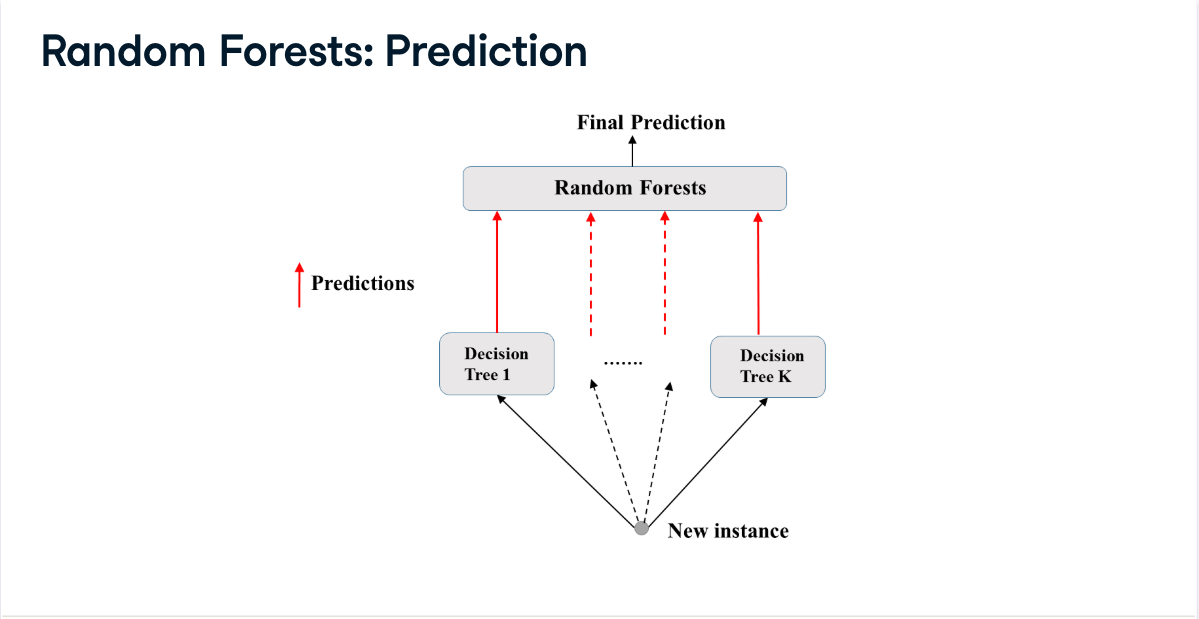


- Once trained predictions can be made on new instances . When a new instance is fed to the training to the different base estimators each of them outputs a prediction . The predictions are then collected by the random forests meta-classifier and a final prediction is made depending on the nature of the problem

# Classification and Regression
### Classification 
- Aggregates predictions by majority voting 
- RandomForestClassifier in sickit-learn

### Regression
- Aggregates predictions through averaging 
- RandomForestRegressor in scikit-learn

In [8]:
SEED = 1
feature = df.drop("mpg",axis=1).values
target = df['mpg'].values

X_train , X_test , y_train , y_test = train_test_split(feature,target,test_size=0.3,random_state=SEED)

# Instantiate a random forest regressor "rf" 400 estimators
rf = RandomForestRegressor(n_estimators=400,min_samples_leaf=0.12,random_state=SEED)

# Fit 'rf' to training set
rf.fit(X_train,y_train)

# Predict the test set labels 'y_pred'
y_pred = rf.predict(X_test)

# Evaluate the test set RMSE

rmse_test = MSE(y_test,y_pred) ** 0.5

print('Test set RMSE of rf : {:.2f}'.format(rmse_test))



Test set RMSE of rf : 3.48


# Feature Importance 
- When a tree based method is trained , the predictive power of a feature or its importance can be assessed . In sickit learn , feature importance is assessed by measuring how much tree nodes use a particular feature to reduce impurity . Note that the importance of a feature is expressed as a percentage indicating the weight of that feature in training and predictions . Once you train a tree-based model in sckit-learn , the features importances can be assessed by extracting the feature_importance_ attribute from the model

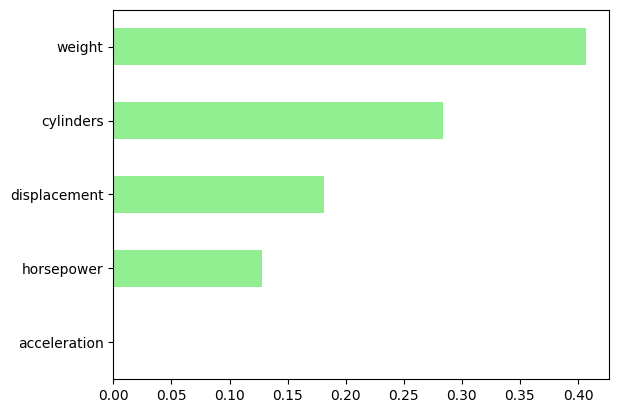

In [11]:
# Create a pd.Series of features importances 
importances_rf = pd.Series(rf.feature_importances_,index=df.drop("mpg",axis=1).columns)

# Sort importances_rf 
sorted_importances_rf = importances_rf.sort_values()

# Make a horizontal bar plot
sorted_importances_rf.plot(kind='barh',color='lightgreen')

plt.show()

